##### The idea of this notebook is to intersect the genebody obtained from DeSeq2 to the chromatin loop anchors and make sense of the biological context of the project

In [1]:
import pandas as pd
import pybedtools
from pybedtools import BedTool
import pyranges as pr
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_v8_loops.csv")
for c in ["start1","end1","start2","end2"]:
    loops[c] = loops[c].astype(int)
loops[["chr1","start1","end1","chr2","start2","end2"]].to_csv(
    "all_loops.bedpe", sep="\t", index=False, header=False
)

In [17]:
# All the file loading
# Load genebody
genebody_up = BedTool("/usr/users/papantonis1/aman/rnaseq_data/up_genes_gencodegtf.bed")
genebody_down = BedTool("/usr/users/papantonis1/aman/rnaseq_data/down_genes_gencodegtf.bed")
# loops -mega ctrl + cpi
#loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv", sep=",")
#loops_short = loops[['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']]
#loops = pd.DataFrame(loops)
# splitting loops to their anchors
#anchor1 = BedTool.from_dataframe(loops[['chr1', 'start1', 'end1']])
#anchor2 = BedTool.from_dataframe(loops[['chr2', 'start2', 'end2']])

In [4]:
#loops

In [19]:
# Extend genebody regions for somewhat good intersection
genebody_up_slop = genebody_up.slop(b=100,genome='hg38')
genebody_down_slop = genebody_down.slop(b=100,genome='hg38')

---

In [6]:
# anchor intersection only
# # === Step 1: Load loop table ===
# loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")

# # Reset index to ensure continuous numbering
# loops = loops.reset_index(drop=True)

# # Now create loop_id from the reset index
# loops["loop_id"] = loops.index.astype(str)

# # Ensure left-to-right loop span for same-chromosome loops
# loops["loop_chr"] = loops["chr1"]
# loops["loop_start"] = loops[["start1", "start2"]].min(axis=1)
# loops["loop_end"] = loops[["end1", "end2"]].max(axis=1)
# loops["loop_id"] = loops.index.astype(str)

# loop_spans = loops[["loop_chr", "loop_start", "loop_end", "loop_id"]]
# loop_bedtool = pybedtools.BedTool.from_dataframe(loop_spans)

# # === Step 2: Load gene body BED files ===
# up = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed", sep="\t", header=None,
#                  names=["chr", "start", "end", "gene_id", "score", "strand"])
# down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed", sep="\t", header=None,
#                    names=["chr", "start", "end", "gene_id", "score", "strand"])
# genes = pd.concat([up, down])
# genes_bed = pybedtools.BedTool.from_dataframe(genes[["chr", "start", "end", "gene_id"]])

# # === Step 3: Intersect loops spans with gene bodies ===
# intersected = loop_bedtool.intersect(genes_bed, u=True)

# # === Step 4: Get matching loop IDs and filter original loops ===
# matched_ids = [f.name for f in intersected]
# final_loops = loops[loops["loop_id"].isin(matched_ids)]

# # Check if any matched_ids are not in original loop_ids
# original_ids = set(loops["loop_id"].astype(str))
# matched_set = set(matched_ids)
# fake_ids = matched_set - original_ids
# if fake_ids:
#     print(f"WARNING: Found {len(fake_ids)} fake IDs: {list(fake_ids)[:5]}")

# # === Step 5: Write output in BEDPE (IGV-compatible) ===
# bedpe_cols = ["chr1", "start1", "end1", "chr2", "start2", "end2"]
# final_loops[bedpe_cols].to_csv("loop_gene_combined_strategy.bedpe", sep="\t", header=False, index=False)


In [7]:
# loop span intersection only
# # Load loops and genes
# loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")
# loops = loops.reset_index(drop=True)
# loops["loop_id"] = loops.index.astype(str)

# up = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed", 
#                  sep="\t", header=None, names=["chr", "start", "end", "gene_id", "score", "strand"])
# down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed", 
#                    sep="\t", header=None, names=["chr", "start", "end", "gene_id", "score", "strand"])
# genes = pd.concat([up, down])

# # Create loop anchors
# anchor1 = loops[["chr1", "start1", "end1", "loop_id"]].copy()
# anchor1.columns = ["chr", "start", "end", "loop_id"]

# anchor2 = loops[["chr2", "start2", "end2", "loop_id"]].copy()
# anchor2.columns = ["chr", "start", "end", "loop_id"]

# # Convert to BedTools
# anchor1_bed = pybedtools.BedTool.from_dataframe(anchor1)
# anchor2_bed = pybedtools.BedTool.from_dataframe(anchor2)
# genes_bed = pybedtools.BedTool.from_dataframe(genes[["chr", "start", "end", "gene_id"]])

# # Find intersections
# intersect1 = anchor1_bed.intersect(genes_bed, u=True)
# intersect2 = anchor2_bed.intersect(genes_bed, u=True)

# # Get loop IDs that intersect with genes
# matched_ids1 = [f.name for f in intersect1]
# matched_ids2 = [f.name for f in intersect2]
# all_matched_ids = list(set(matched_ids1 + matched_ids2))

# # Filter and save
# final_loops = loops[loops["loop_id"].isin(all_matched_ids)]
# final_loops[["chr1", "start1", "end1", "chr2", "start2", "end2"]].to_csv(
#     "loop_gene_fixed.bedpe", sep="\t", header=False, index=False)

# print(f"Found {len(final_loops)} loops intersecting with genes (out of {len(loops)} total)")

In [8]:
#  # Same logic as before but instead of bedtools using pyranges for more readability
#  # Load loops and genes
# loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")
# loops = loops.reset_index(drop=True)
# loops["loop_id"] = loops.index.astype(str)

# up = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed", 
#                  sep="\t", header=None, names=["chr", "start", "end", "gene_id", "score", "strand"])
# down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed", 
#                    sep="\t", header=None, names=["chr", "start", "end", "gene_id", "score", "strand"])
# genes = pd.concat([up, down])

# # Prepare loop anchors for intersection
# anchor1 = loops[["chr1", "start1", "end1", "loop_id"]].copy()
# anchor1.columns = ["Chromosome", "Start", "End", "loop_id"]

# anchor2 = loops[["chr2", "start2", "end2", "loop_id"]].copy()
# anchor2.columns = ["Chromosome", "Start", "End", "loop_id"]

# # Prepare genes for intersection
# genes_gr = pr.PyRanges(genes.rename(columns={"chr": "Chromosome", "start": "Start", "end": "End"}))

# # Convert anchors to PyRanges
# anchor1_gr = pr.PyRanges(anchor1)
# anchor2_gr = pr.PyRanges(anchor2)

# # Perform intersection
# intersect1 = anchor1_gr.join(genes_gr)
# intersect2 = anchor2_gr.join(genes_gr)

# # Get unique loop IDs with intersected genes
# matched_ids1 = intersect1.df["loop_id"].unique().tolist()
# matched_ids2 = intersect2.df["loop_id"].unique().tolist()
# all_matched_ids = list(set(matched_ids1 + matched_ids2))

# # Filter loops
# final_loops = loops[loops["loop_id"].isin(all_matched_ids)]

# # Save to BEDPE
# final_loops[["chr1", "start1", "end1", "chr2", "start2", "end2"]].to_csv(
#     "loop_gene_fixed.bedpe", sep="\t", header=False, index=False
# )

# print(f"Found {len(final_loops)} loops intersecting with genes (out of {len(loops)} total)")


In [20]:
# Load loops and gene bodies
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv")
loops = loops.reset_index(drop=True)
loops["loop_id"] = loops.index.astype(str)

up = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/up_genes_gencodegtf.bed", sep="\t", header=None,
                 names=["chr", "start", "end", "gene_id", "score", "strand"])
down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/down_genes_gencodegtf.bed", sep="\t", header=None,
                   names=["chr", "start", "end", "gene_id", "score", "strand"])
genes = pd.concat([up, down])
genes_bed = pybedtools.BedTool.from_dataframe(genes[["chr", "start", "end", "gene_id"]])

# 1. Span intersection
loops["loop_chr"] = loops["chr1"]
loops["loop_start"] = loops[["start1", "start2"]].min(axis=1)
loops["loop_end"] = loops[["end1", "end2"]].max(axis=1)
span_bed = pybedtools.BedTool.from_dataframe(
    loops[["loop_chr", "loop_start", "loop_end", "loop_id"]]
)

span_ids = {f.name for f in span_bed.intersect(genes_bed, u=True)}

# 2. Anchor intersection
anchor1 = loops[["chr1", "start1", "end1", "loop_id"]].copy()
anchor1.columns = ["chr", "start", "end", "loop_id"]
anchor2 = loops[["chr2", "start2", "end2", "loop_id"]].copy()
anchor2.columns = ["chr", "start", "end", "loop_id"]
anchor1_bed = pybedtools.BedTool.from_dataframe(anchor1)
anchor2_bed = pybedtools.BedTool.from_dataframe(anchor2)

anchor1_ids = {f.name for f in anchor1_bed.intersect(genes_bed, u=True)}
anchor2_ids = {f.name for f in anchor2_bed.intersect(genes_bed, u=True)}

# Combine all matches (union)
all_matched_ids = span_ids | anchor1_ids | anchor2_ids

# Filter and export
final_loops = loops[loops["loop_id"].isin(all_matched_ids)]
final_loops[["chr1", "start1", "end1", "chr2", "start2", "end2"]].to_csv(
    "loopspan&anchorbased_intersection_withgeneB_gtfgencode.bedpe", sep="\t", header=False, index=False
)
print(f"Exported {len(final_loops)} loops where span OR either anchor overlaps a gene.")

Exported 1284 loops where span OR either anchor overlaps a gene.


In [21]:
final_loops

KeyboardInterrupt: 

In [21]:
len(final_loops)

1284

/tmp/ipykernel_1901944/1817863754.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(status_counts.index, rotation=45, ha='right')


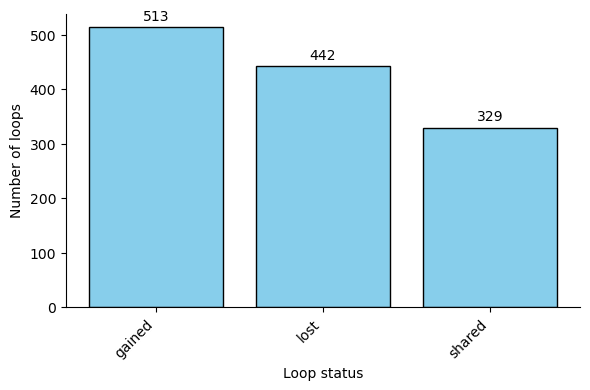

In [22]:
# Count the frequency of each status
status_counts = final_loops['status'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(status_counts.index, status_counts.values, color='skyblue', edgecolor='black')

# Add counts on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Remove top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Labels and formatting
#ax.set_title('Loop Status Distribution')
ax.set_xlabel('Loop status')
ax.set_ylabel('Number of loops')
ax.set_xticklabels(status_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()


/tmp/ipykernel_1901944/101568939.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(status_counts.index, rotation=45, ha='right')


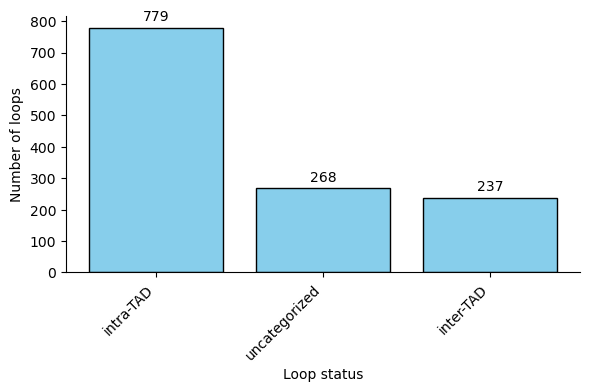

In [23]:
# Count the frequency of each status
status_counts = final_loops['loop_class'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(status_counts.index, status_counts.values, color='skyblue', edgecolor='black')

# Add counts on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Remove top and right spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Labels and formatting
#ax.set_title('Loop Status Distribution')
ax.set_xlabel('Loop status')
ax.set_ylabel('Number of loops')
ax.set_xticklabels(status_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()


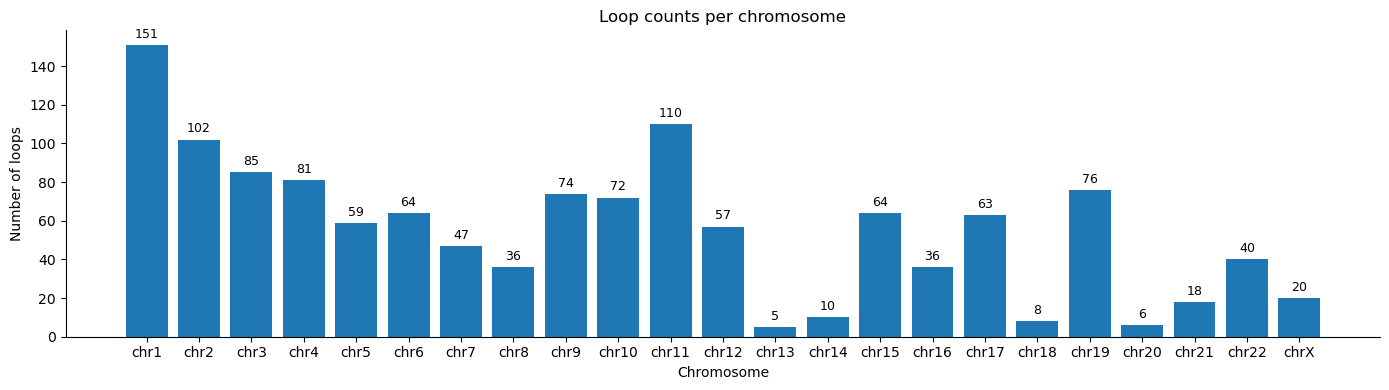

In [24]:
chrom_counts = final_loops['chr1'].value_counts()
chrom_order = [f'chr{i}' for i in range(1, 23)] + ['chrX']
chrom_counts = chrom_counts.reindex(chrom_order, fill_value=0)

plt.figure(figsize=(14, 4))
bars = plt.bar(chrom_counts.index, chrom_counts.values)
plt.ylabel('Number of loops')
plt.xlabel('Chromosome')
plt.title('Loop counts per chromosome')

# Add counts on top of bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(
        f'{int(height)}',
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha='center', va='bottom', fontsize=9
    )

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# signal_cols_main = ['CTCF_signal', 'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal']

# # Melt data
# main_data = final_loops[signal_cols_main].melt(var_name='Signal', value_name='Value')
# main_data = main_data[main_data['Value'] > 0]

# # Subplots for each signal
# fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# for ax, signal in zip(axes.flatten(), signal_cols_main):
#     data = main_data[main_data['Signal'] == signal]
#     sns.violinplot(y='Value', data=data, ax=ax, inner='quartile', cut=0)
#     ax.set_yscale('log')
#     ax.set_title(signal)
#     ax.set_xlabel('')
#     ax.set_ylabel('Value')

# plt.tight_layout()
# plt.show()


In [27]:
import pandas as pd
import pybedtools

# --- 1) Load loops ---
loops = pd.read_csv(
    "/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_v8_loops.csv"
)
loops = loops.reset_index(drop=True)
loops["loop_id"] = loops.index.astype(str)

# Loop span
span = pd.DataFrame({
    "chrom": loops["chr1"],
    "start": loops[["start1", "start2"]].min(axis=1).astype(int),
    "end":   loops[["end1",   "end2"  ]].max(axis=1).astype(int),
    "name":  loops["loop_id"].astype(str)
})
a1 = loops[["chr1","start1","end1","loop_id"]].rename(
    columns={"chr1":"chrom","start1":"start","end1":"end","loop_id":"name"}
)
a2 = loops[["chr2","start2","end2","loop_id"]].rename(
    columns={"chr2":"chrom","start2":"start","end2":"end","loop_id":"name"}
)
for df in (span, a1, a2):
    df["start"] = df["start"].astype(int)
    df["end"]   = df["end"].astype(int)
    df.sort_values(["chrom","start","end"], inplace=True)

span_bed = pybedtools.BedTool.from_dataframe(span)
a1_bed   = pybedtools.BedTool.from_dataframe(a1)
a2_bed   = pybedtools.BedTool.from_dataframe(a2)

# --- 2) Load gene bodies (BED6 made earlier) ---
up = pd.read_csv(
    "/usr/users/papantonis1/aman/rnaseq_data/up_genes_gencodegtf.bed",
    sep="\t", header=None,
    names=["chrom","start","end","name","score","strand"]
)
down = pd.read_csv(
    "/usr/users/papantonis1/aman/rnaseq_data/down_genes_gencodegtf.bed",
    sep="\t", header=None,
    names=["chrom","start","end","name","score","strand"]
)
genes = pd.concat([up, down], ignore_index=True)[["chrom","start","end","name"]]
genes["start"] = genes["start"].astype(int)
genes["end"]   = genes["end"].astype(int)
genes.sort_values(["chrom","start","end"], inplace=True)
genes_bed = pybedtools.BedTool.from_dataframe(genes)

# --- 3) Intersections keeping gene IDs ---
def hit_df(loop_bed, region_label):
    # -wa -wb gives 8 cols: loop(4) + gene(4)
    res = loop_bed.intersect(genes_bed, wa=True, wb=True, sorted=False)
    df = res.to_dataframe(
        names=["l_chrom","l_start","l_end","loop_id",
               "g_chrom","g_start","g_end","gene_id"]
    )
    df["region"] = region_label
    return df

span_hits = hit_df(span_bed, "span")
a1_hits   = hit_df(a1_bed,   "anchor1")
a2_hits   = hit_df(a2_bed,   "anchor2")

all_hits = pd.concat([span_hits, a1_hits, a2_hits], ignore_index=True)
all_hits.drop_duplicates(["loop_id","gene_id","region"], inplace=True)

# Aggregate gene IDs per loop
gene_agg = (all_hits.groupby("loop_id")["gene_id"]
            .agg(lambda x: ",".join(sorted(set(map(str, x)))))
            .reset_index())

# Merge back to loops and keep only loops with a gene
loops["loop_id"] = loops["loop_id"].astype(str)
gene_agg["loop_id"] = gene_agg["loop_id"].astype(str)

out = loops.merge(gene_agg, on="loop_id", how="inner")

out.to_csv("loops_with_gene_info_genelevel_gtfgencode.csv", index=False)
print(f"Exported {len(out)} loops with gene information.")

Exported 1284 loops with gene information.


In [29]:
import pandas as pd
import pybedtools

# Load loops
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_v8_loops.csv")
loops = loops.reset_index(drop=True)
loops["loop_id"] = loops.index.astype(str)

# Load gene body annotations (up & down)
up = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/up_genes_gencodegtf.bed", sep="\t", header=None,
                 names=["chr", "start", "end", "gene_id", "score", "strand"])
down = pd.read_csv("/usr/users/papantonis1/aman/rnaseq_data/down_genes_gencodegtf.bed", sep="\t", header=None,
                   names=["chr", "start", "end", "gene_id", "score", "strand"])
genes = pd.concat([up, down], ignore_index=True)

# Build BEDTool for intersection
genes_bed = pybedtools.BedTool.from_dataframe(genes[["chr", "start", "end", "gene_id"]])

# === change made ===
# Keep full gene chromosome info for correct merge later
genes_df = genes[["chr", "start", "end", "gene_id"]].copy()  # change made
genes_df.columns = ["gene_chr", "gene_start", "gene_end", "gene_id"]  # change made

# Prepare loop span
loops["loop_chr"] = loops["chr1"]
loops["loop_start"] = loops[["start1", "start2"]].min(axis=1)
loops["loop_end"] = loops[["end1", "end2"]].max(axis=1)
span_bed = pybedtools.BedTool.from_dataframe(loops[["loop_chr", "loop_start", "loop_end", "loop_id"]])

# Prepare anchor beds
anchor1 = loops[["chr1", "start1", "end1", "loop_id"]].copy()
anchor1.columns = ["chr", "start", "end", "loop_id"]
anchor2 = loops[["chr2", "start2", "end2", "loop_id"]].copy()
anchor2.columns = ["chr", "start", "end", "loop_id"]
anchor1_bed = pybedtools.BedTool.from_dataframe(anchor1)
anchor2_bed = pybedtools.BedTool.from_dataframe(anchor2)

# Function to intersect and retain correct gene_chr info
def intersect_with_genes(loop_bed, label):
    res = loop_bed.intersect(genes_bed, wa=True, wb=True)
    
    # === change made ===
    # Placeholder column names for gene_chr; real info will be merged in
    df = res.to_dataframe(names=[
        'loop_chr', 'loop_start', 'loop_end', 'loop_id',
        '_gchr', '_gstart', '_gend', 'gene_id'  # change made
    ])
    
    # === change made ===
    # Merge real gene_chr info from source gene dataframe
    df = df.merge(genes_df, on='gene_id', how='left')  # change made
    
    # === change made ===
    # Keep only intra-chromosomal hits
    df = df[df['loop_chr'] == df['gene_chr']]  # change made

    df['region'] = label
    return df

# Perform intersections
span_hits = intersect_with_genes(span_bed, 'span')
a1_hits = intersect_with_genes(anchor1_bed, 'anchor1')
a2_hits = intersect_with_genes(anchor2_bed, 'anchor2')

# Combine all hits
all_hits = pd.concat([span_hits, a1_hits, a2_hits], ignore_index=True)
all_hits = all_hits.drop_duplicates(['loop_id', 'gene_id', 'region'])

# Aggregate gene assignments per loop
gene_agg = all_hits.groupby('loop_id')['gene_id'].agg(lambda x: ','.join(sorted(set(x)))).reset_index()

# Merge back to loops
loops['loop_id'] = loops['loop_id'].astype(str)
gene_agg['loop_id'] = gene_agg['loop_id'].astype(str)
loops_with_genes = loops[loops["loop_id"].isin(gene_agg["loop_id"])]
loops_with_genes = loops_with_genes.merge(gene_agg, how='left', on='loop_id')

# Export result
loops_with_genes.to_csv("loops_with_gene_info_genelevel_auxincpi.cleaned.csv", index=False)
print(f"Exported {len(loops_with_genes)} loops with intra-chromosomal gene assignments.")


Exported 1284 loops with intra-chromosomal gene assignments.
